***Objective***
## Grammar Scoring Engine for spoken data samples


- You are provided with an audio dataset where each file is between 45 to 60 seconds long. 
- The ground truth labels are MOS Likert Grammar Scores for each audio instance
- build a model that takes an audio file as input and outputs a continuous score ranging from 0 to 5.


In [1]:

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)





**Inference - What the training data looks like**

In [2]:
# Load datasets
train_df = pd.read_csv('/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv')

train_df.head(10)


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0
5,audio_639.wav,2.5
6,audio_703.wav,2.0
7,audio_509.wav,3.0
8,audio_672.wav,4.0
9,audio_344.wav,4.0


In [3]:
test_df[test_df['label'] == 0].head()

,filename,label


**Inference - test labels are hidden**

**Grammar Score Summary**


1 – Very Poor: Struggles with basic sentence structure and grammar.

2 – Poor: Uses simple structures but makes frequent basic grammar and sentence errors.

3 – Average: Understands grammar reasonably well but makes noticeable structural or grammatical mistakes.

4 – Good: Strong grammar and sentence structure; only minor occasional errors.

5 – Excellent: Highly accurate grammar, handles complex sentences well, and rarely makes mistakes.

In [4]:
train_df['label'].value_counts()


label
3.0    174
5.0    133
4.0    124
2.0    102
2.5     79
3.5     64
4.5     52
0.0     37
1.5      3
1.0      1
Name: count, dtype: int64

**regression/scoring problem**

In [5]:
train_df.info()
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filename  769 non-null    object 
 1   label     769 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  216 non-null    object
 1   label     216 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [6]:
print("Missing values in training data:\n", train_df.isnull().sum())

Missing values in training data:
 filename    0
label       0
dtype: int64


In [7]:
test_df.isnull().sum()


filename    0
label       0
dtype: int64

**training & test data is complete**

In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'audio_447.wav':
            print(os.path.join(dirname, filename))


/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_447.wav


**Audio file → person's speech → grammar score**

continuous regression problem - decimal values

## > listening

In [9]:
import IPython.display as ipd

audio_path1 = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_447.wav'

ipd.Audio(audio_path1)

## score given is 3.5

In [10]:
import librosa

audio, sr = librosa.load(audio_path1, sr=None)

print("Sample rate:", sr)
print("Audio length:", len(audio) / sr, "seconds")


Sample rate: 16000
Audio length: 60.0746875 seconds


In [11]:
audio_path2 = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_592.wav'

ipd.Audio(audio_path2)


## score given = 5.0

In [12]:
audio, sr = librosa.load(audio_path2, sr=None)

print("Sample rate:", sr)
print("Audio length:", len(audio) / sr, "seconds")

Sample rate: 16000
Audio length: 60.0746875 seconds


In [13]:
audio_path3 = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_126.wav'

ipd.Audio(audio_path3)

## score = 2.0

In [14]:
audio, sr = librosa.load(audio_path3, sr=None)

print("Sample rate:", sr)
print("Audio length:", len(audio) / sr, "seconds")

Sample rate: 16000
Audio length: 45.06 seconds


In [15]:
audio_path4 = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_5055.wav'

ipd.Audio(audio_path4)

## score = 0.0

In [16]:
audio, sr = librosa.load(audio_path4, sr=None)

print("Sample rate:", sr)
print("Audio length:", len(audio) / sr, "seconds")


Sample rate: 16000
Audio length: 60.08 seconds


In [17]:
results = []

audio_folder = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train'

for _, row in train_df.iterrows():
    file_path = os.path.join(audio_folder, row['filename'])
    
    audio, sr = librosa.load(file_path, sr=None)
    length = len(audio) / sr
    
    results.append({
        'filename': row['filename'],
        'score': row['label'],
        'length_seconds': length
    })

audio_df = pd.DataFrame(results)

audio_df.head()


,filename,score,length_seconds
0,audio_192.wav,3.0,60.508375
1,audio_436.wav,3.0,60.074688
2,audio_447.wav,3.5,60.074688
3,audio_126.wav,2.0,45.060000
4,audio_61.wav,2.0,45.300000


In [18]:
audio_df['length_group'] = pd.cut(
    audio_df['length_seconds'],
    bins=[0, 50, 60, float('inf')],
    labels=['<50 sec', '50-60 sec', '>60 sec']
)


In [19]:
audio_df.head()


,filename,score,length_seconds,length_group
0,audio_192.wav,3.0,60.508375,>60 sec
1,audio_436.wav,3.0,60.074688,>60 sec
2,audio_447.wav,3.5,60.074688,>60 sec
3,audio_126.wav,2.0,45.060000,<50 sec
4,audio_61.wav,2.0,45.300000,<50 sec


In [20]:
audio_df['length_group'].value_counts()


length_group
>60 sec      544
<50 sec      182
50-60 sec     43
Name: count, dtype: int64

In [21]:
audio_df['length_group'] = pd.cut(
    audio_df['length_seconds'],
    bins=[0, 30, 45, 60, 90, float('inf')],
    labels=['<30 sec', '30-45 sec', '45-60 sec', '60-90 sec', '>90 sec']
)

In [22]:
audio_df.groupby('length_group')['score'].describe()


/tmp/ipykernel_23/1086701752.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audio_df.groupby('length_group')['score'].describe()


,count,mean,std,min,25%,50%,75%,max
length_group,,,,,,,,
<30 sec,14.0,3.178571,1.202676,0.0,2.625,4.0,4.0,4.0
30-45 sec,57.0,3.192982,1.007802,0.0,2.500,3.0,4.0,5.0
45-60 sec,154.0,3.120130,1.090744,0.0,2.500,3.0,4.0,5.0
60-90 sec,544.0,3.384191,1.295767,0.0,2.500,3.5,4.5,5.0
>90 sec,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


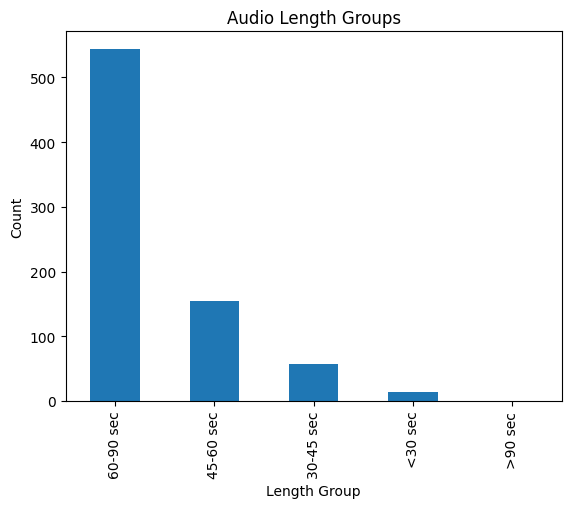

In [23]:
import matplotlib.pyplot as plt
audio_df['length_group'].value_counts().plot(kind='bar')

plt.xlabel('Length Group')
plt.ylabel('Count')
plt.title('Audio Length Groups')
plt.show()

In [24]:
audio_df['length_group'] = pd.cut(
    audio_df['length_seconds'],
    bins=[0, 30, 45, 60, float('inf')],
    labels=['<30 sec', '30-45 sec', '45-60 sec', '60-90 sec']
)

In [25]:
audio_df.columns

Index(['filename', 'score', 'length_seconds', 'length_group'], dtype='object')

### **whether audio length is related to rating**

/tmp/ipykernel_23/689253097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audio_df.groupby('length_group')['score'].mean().plot(kind='bar')


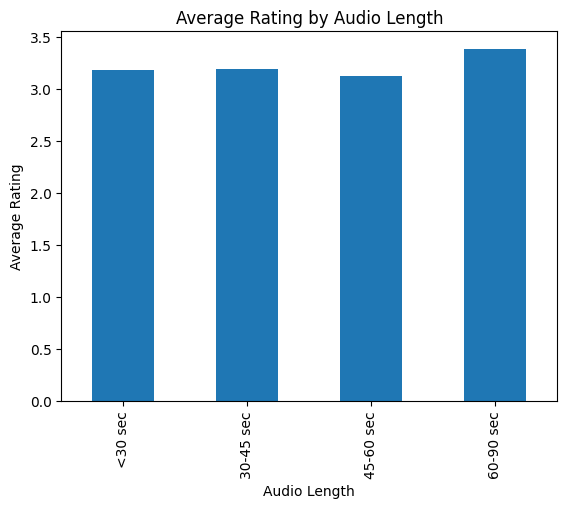

In [26]:
audio_df.groupby('length_group')['score'].mean().plot(kind='bar')

plt.ylabel('Average Rating')
plt.xlabel('Audio Length')
plt.title('Average Rating by Audio Length')
plt.show()

In [27]:
audio_df.groupby('length_group')['score'].describe()

/tmp/ipykernel_23/338035704.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audio_df.groupby('length_group')['score'].describe()


,count,mean,std,min,25%,50%,75%,max
length_group,,,,,,,,
<30 sec,14.0,3.178571,1.202676,0.0,2.625,4.0,4.0,4.0
30-45 sec,57.0,3.192982,1.007802,0.0,2.500,3.0,4.0,5.0
45-60 sec,154.0,3.120130,1.090744,0.0,2.500,3.0,4.0,5.0
60-90 sec,544.0,3.384191,1.295767,0.0,2.500,3.5,4.5,5.0


- longer audio (60–90 sec) has the highest average rating in this dataset.
- 45 - 60 range is oddly less

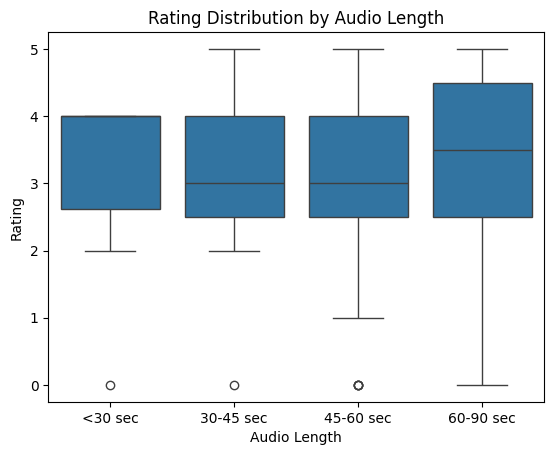

In [28]:
import seaborn as sns

sns.boxplot(data=audio_df, x='length_group', y='score')

plt.xlabel('Audio Length')
plt.ylabel('Rating')
plt.title('Rating Distribution by Audio Length')
plt.show()

In [29]:
audio_df['score'].value_counts().sort_index()

score
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64

**What scores are most common**

Ans = 3.0

<Axes: xlabel='score'>

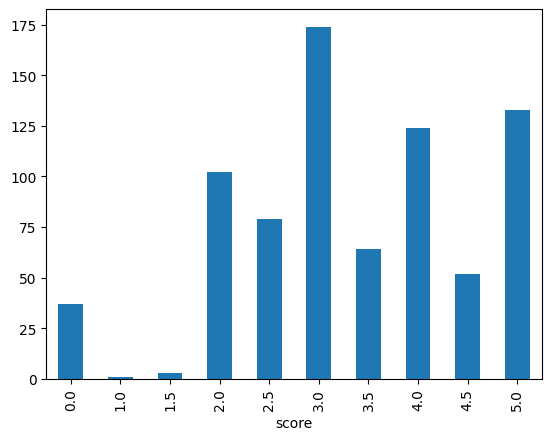

In [30]:
audio_df['score'].value_counts().sort_index().plot(kind='bar')

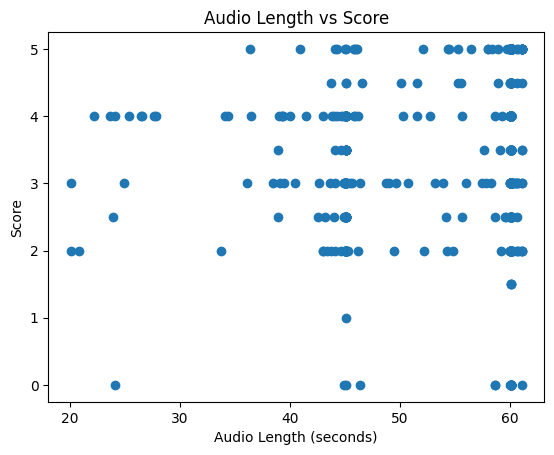

In [31]:
plt.scatter(audio_df['length_seconds'], audio_df['score'])

plt.xlabel('Audio Length (seconds)')
plt.ylabel('Score')
plt.title('Audio Length vs Score')
plt.show()

In [32]:
correlation = audio_df['length_seconds'].corr(audio_df['score'])

print(correlation)

0.08738017478734521


**overall, longer audio does not consistently mean higher score.**

## Audio length - score : No

In [33]:
audio_df.groupby('length_group')['score'].agg(['count', 'mean', 'median', 'std'])

/tmp/ipykernel_23/5342854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audio_df.groupby('length_group')['score'].agg(['count', 'mean', 'median', 'std'])


,count,mean,median,std
length_group,,,,
<30 sec,14,3.178571,4.0,1.202676
30-45 sec,57,3.192982,3.0,1.007802
45-60 sec,154,3.120130,3.0,1.090744
60-90 sec,544,3.384191,3.5,1.295767


In [34]:
pd.crosstab(audio_df['length_group'], audio_df['score'])

score,0.0,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
length_group,,,,,,,,,,
<30 sec,1,0,0,2,1,2,0,8,0,0
30-45 sec,1,0,0,10,8,14,3,15,1,5
45-60 sec,4,1,0,32,20,35,13,26,8,15
60-90 sec,31,0,3,58,50,123,48,75,43,113


In [35]:
pd.crosstab(
    audio_df['length_group'],
    audio_df['score'],
    normalize='index'
) * 100

score,0.0,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
length_group,,,,,,,,,,
<30 sec,7.142857,0.000000,0.000000,14.285714,7.142857,14.285714,0.000000,57.142857,0.000000,0.000000
30-45 sec,1.754386,0.000000,0.000000,17.543860,14.035088,24.561404,5.263158,26.315789,1.754386,8.771930
45-60 sec,2.597403,0.649351,0.000000,20.779221,12.987013,22.727273,8.441558,16.883117,5.194805,9.740260
60-90 sec,5.698529,0.000000,0.551471,10.661765,9.191176,22.610294,8.823529,13.786765,7.904412,20.772059


In [36]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Target
y = train_df["label"]

# Train/validation split
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20,
    random_state=42
)

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

# Mean-score baseline
baseline_prediction = y_train.mean()

# Predict the same mean for every validation sample
val_pred = np.full(len(y_val), baseline_prediction)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Baseline prediction:", baseline_prediction)
print("Validation RMSE:", rmse)
print("Validation Pearson: Not applicable for constant predictions")

Baseline prediction: 3.33739837398374
Validation RMSE: 1.3596105941011667
Validation Pearson: Not applicable for constant predictions


**Any useful model should beat RMSE 1.36**

In [37]:
TRAIN_AUDIO_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train"

def extract_audio_features(filename):
    path = os.path.join(TRAIN_AUDIO_DIR, filename)

    y, sr = librosa.load(path, sr=16000)

    features = {}

    # Duration
    features["duration"] = len(y) / sr

    # RMS energy
    rms = librosa.feature.rms(y=y)[0]
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    return features


audio_features = []

for i, filename in enumerate(train_df["filename"]):
    try:
        features = extract_audio_features(filename)
        features["filename"] = filename
        audio_features.append(features)
    except Exception as e:
        print("Error:", filename, e)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(train_df)}")


audio_features_df = pd.DataFrame(audio_features)

print("\nFeature shape:", audio_features_df.shape)
audio_features_df.head()

Processed 100/769
Processed 200/769
Processed 300/769
Processed 400/769
Processed 500/769
Processed 600/769
Processed 700/769

Feature shape: (769, 32)


,duration,rms_mean,rms_std,zcr_mean,zcr_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,filename
0,60.508375,0.031786,0.038404,0.084768,0.053518,-403.835876,121.629181,103.576317,68.035660,-14.213526,...,9.175093,-6.111349,7.005802,-11.947042,8.755231,-8.226156,6.883492,-6.238203,5.747041,audio_192.wav
1,60.074688,0.068651,0.055423,0.142977,0.127519,-287.111023,81.686005,72.087601,56.021065,5.334724,...,16.002327,-8.470199,13.448155,-9.261224,11.554407,-9.040758,13.295260,4.751498,13.532232,audio_436.wav
2,60.074688,0.054421,0.051533,0.146870,0.129777,-324.808228,86.514740,97.828194,59.010967,18.635796,...,16.530882,-8.570185,16.668097,3.306297,13.158398,-3.113312,11.855078,-0.866495,11.763124,audio_447.wav
3,45.060000,0.013778,0.012183,0.059477,0.036870,-489.320648,124.842300,111.792908,53.296017,0.751581,...,15.149113,-21.515909,15.097207,-12.347360,11.821060,-9.993058,10.599061,-17.710951,11.394984,audio_126.wav
4,45.300000,0.009330,0.008970,0.169988,0.128430,-483.866028,159.520401,51.975899,58.754555,-21.642136,...,16.179859,-18.795963,16.087770,-8.590364,13.599858,3.873606,10.692766,-17.764481,15.302751,audio_61.wav


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Merge audio features with labels
audio_model_df = audio_features_df.merge(
    train_df[["filename", "label"]],
    on="filename",
    how="inner"
)

# Features and target
X = audio_model_df.drop(columns=["filename", "label"])
y = audio_model_df["label"]

# Use the same train/validation split as our baseline
X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

# Train model
audio_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

audio_model.fit(X_train, y_train)

# Validation prediction
val_pred = audio_model.predict(X_val)

# Keep predictions in valid score range
val_pred = np.clip(val_pred, 0, 5)

# RMSE
rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Audio-only validation RMSE:", rmse)

Audio-only validation RMSE: 0.740612571132492


In [39]:
from scipy.stats import pearsonr

# Training predictions
train_pred = audio_model.predict(X_train)
train_pred = np.clip(train_pred, 0, 5)

# Validation predictions
val_pred = audio_model.predict(X_val)
val_pred = np.clip(val_pred, 0, 5)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

# Pearson
val_pearson = pearsonr(y_val, val_pred)[0]

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Validation Pearson:", val_pearson)

Training RMSE: 0.2987126001354392
Validation RMSE: 0.740612571132492
Validation Pearson: 0.8378159968971469


- acoustic features contain substantial predictive information for this dataset
- overfitting

In [40]:

base = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
test_filenames = set(test_df["filename"])

for dirname, _, filenames in os.walk(base):
    matches = test_filenames.intersection(filenames)
    if matches:
        print("Possible test audio folder:", dirname)
        print("Matching test files:", len(matches))

Possible test audio folder: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
Matching test files: 216
Possible test audio folder: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
Matching test files: 212


## extract test audio features

In [41]:
TEST_AUDIO_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test"

def extract_audio_features(filename, audio_dir):
    path = os.path.join(audio_dir, filename)

    y, sr = librosa.load(path, sr=16000)

    features = {}
    features["duration"] = len(y) / sr

    rms = librosa.feature.rms(y=y)[0]
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    return features

In [42]:
test_audio_features = []

for i, filename in enumerate(test_df["filename"]):
    try:
        features = extract_audio_features(filename, TEST_AUDIO_DIR)
        features["filename"] = filename
        test_audio_features.append(features)
    except Exception as e:
        print("Error:", filename, e)

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(test_df)}")

test_audio_features_df = pd.DataFrame(test_audio_features)

print("Shape:", test_audio_features_df.shape)
print(test_audio_features_df.head())

Processed 50/216
Processed 100/216
Processed 150/216
Processed 200/216
Shape: (216, 32)
    duration  rms_mean   rms_std  zcr_mean   zcr_std  mfcc_1_mean  mfcc_1_std  \
0  45.060000  0.018476  0.018033  0.091145  0.061664  -428.909546  111.767815   
1  44.969313  0.046379  0.045599  0.186478  0.134429  -367.251953  104.920891   
2  45.012000  0.048284  0.044188  0.162025  0.082149  -290.531036  116.555382   
3  58.980000  0.005259  0.005214  0.159751  0.109905  -473.427002   74.835983   
4  45.040000  0.058809  0.038030  0.064533  0.065902  -277.762115  101.525932   

   mfcc_2_mean  mfcc_2_std  mfcc_3_mean  ...  mfcc_9_std  mfcc_10_mean  \
0   114.976288   50.469704     0.369851  ...   10.750963     -8.662834   
1    75.927010   57.165401    10.536559  ...   17.222078    -18.275991   
2    96.616852   54.442101   -34.467869  ...   13.497080    -10.828346   
3    80.182892   39.629742   -11.148033  ...    9.221683     -1.623225   
4   125.968925   42.927631     6.506187  ...   14.19073

# Checkpoint 1: Audio-only Random Forest submission.

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Training features
X_train_full = audio_model_df.drop(columns=["filename", "label"])
y_train_full = audio_model_df["label"]

# Test features
X_test = test_audio_features_df.drop(columns=["filename"])

# Train final audio-only model
final_audio_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_audio_model.fit(X_train_full, y_train_full)

# Training predictions
train_pred_full = final_audio_model.predict(X_train_full)
train_pred_full = np.clip(train_pred_full, 0, 5)

# Required training RMSE
train_rmse = np.sqrt(
    mean_squared_error(y_train_full, train_pred_full)
)

print("Training RMSE:", train_rmse)

Training RMSE: 0.2850313388194933


In [44]:
test_pred = final_audio_model.predict(X_test)
test_pred = np.clip(test_pred, 0, 5)

print("Number of predictions:", len(test_pred))
print("Minimum prediction:", test_pred.min())
print("Maximum prediction:", test_pred.max())
print("First 10 predictions:", test_pred[:10])

Number of predictions: 216
Minimum prediction: 2.4425
Maximum prediction: 4.48
First 10 predictions: [3.2275 4.025  3.48   2.4425 2.9975 2.9125 3.0025 3.135  3.415  3.3625]


In [45]:
submission_audio_rf = pd.DataFrame({
    "filename": test_df["filename"],
    "label": test_pred
})

submission_path = "/kaggle/working/submission_audio_rf.csv"

submission_audio_rf.to_csv(
    submission_path,
    index=False
)

print(submission_audio_rf.head())
print("Shape:", submission_audio_rf.shape)
print("Saved to:", submission_path)

        filename   label
0  audio_128.wav  3.2275
1  audio_156.wav  4.0250
2   audio_19.wav  3.4800
3  audio_108.wav  2.4425
4  audio_206.wav  2.9975
Shape: (216, 2)
Saved to: /kaggle/working/submission_audio_rf.csv


In [46]:
print("Columns:", submission_audio_rf.columns.tolist())
print("Rows:", len(submission_audio_rf))
print("Missing values:")
print(submission_audio_rf.isna().sum())

Columns: ['filename', 'label']
Rows: 216
Missing values:
filename    0
label       0
dtype: int64


In [47]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train, y_train)

val_pred_extra = extra_model.predict(X_val)

rmse_extra = mean_squared_error(y_val, val_pred_extra) ** 0.5
pearson_extra = pearsonr(y_val, val_pred_extra)[0]

print("Extra Trees Validation RMSE:", rmse_extra)
print("Extra Trees Validation Pearson:", pearson_extra)

Extra Trees Validation RMSE: 0.6813323834508505
Extra Trees Validation Pearson: 0.8661758720626154


In [48]:
train_pred_extra = extra_model.predict(X_train)

rmse_train_extra = mean_squared_error(y_train, train_pred_extra) ** 0.5

print("Extra Trees Training RMSE:", rmse_train_extra)

Extra Trees Training RMSE: 0.0


#### Step 1 less complex Extra Trees model

In [49]:
tuned_extra_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

tuned_extra_model.fit(X_train, y_train)

val_pred_tuned = tuned_extra_model.predict(X_val)

rmse_tuned = mean_squared_error(y_val, val_pred_tuned) ** 0.5
pearson_tuned = pearsonr(y_val, val_pred_tuned)[0]

train_pred_tuned = tuned_extra_model.predict(X_train)
train_rmse_tuned = mean_squared_error(y_train, train_pred_tuned) ** 0.5

print("Tuned Extra Trees Validation RMSE:", rmse_tuned)
print("Tuned Extra Trees Validation Pearson:", pearson_tuned)
print("Tuned Extra Trees Training RMSE:", train_rmse_tuned)

Tuned Extra Trees Validation RMSE: 0.7013827539794931
Tuned Extra Trees Validation Pearson: 0.8573763345211098
Tuned Extra Trees Training RMSE: 0.23575022802863924


***Keep the original Extra Trees model.***

In [50]:
extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train, y_train)

val_pred_extra = extra_model.predict(X_val)

rmse_extra = mean_squared_error(y_val, val_pred_extra) ** 0.5
pearson_extra = pearsonr(y_val, val_pred_extra)[0]

print("Extra Trees Validation RMSE:", rmse_extra)
print("Extra Trees Validation Pearson:", pearson_extra)

Extra Trees Validation RMSE: 0.6813323834508505
Extra Trees Validation Pearson: 0.8661758720626154


Which audio characteristics are actually helping the model predict grammar scores

In [51]:
importance = pd.Series(
    extra_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

mfcc_2_std     0.102309
zcr_mean       0.100508
mfcc_1_mean    0.076654
mfcc_3_std     0.061073
mfcc_1_std     0.044669
mfcc_4_std     0.042753
mfcc_7_std     0.039161
mfcc_8_std     0.037591
mfcc_5_std     0.035999
mfcc_6_std     0.035995
dtype: float64


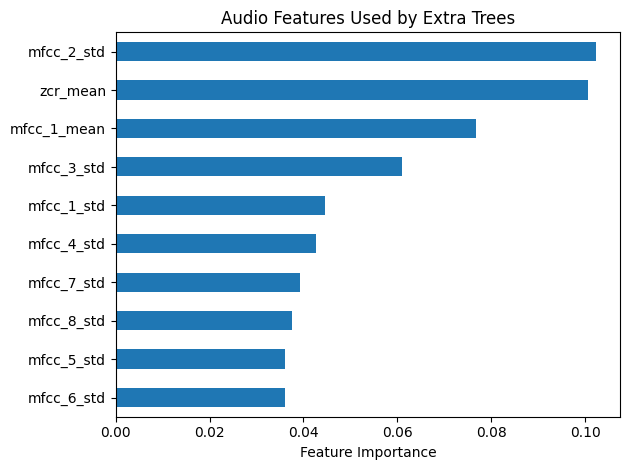

In [52]:
importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Audio Features Used by Extra Trees")
plt.tight_layout()
plt.show()

In [53]:
final_extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_extra_model.fit(X_train_full, y_train_full)

test_pred_extra = final_extra_model.predict(X_test)
test_pred_extra = np.clip(test_pred_extra, 0, 5)

In [54]:
print("Min:", test_pred_extra.min())
print("Max:", test_pred_extra.max())
print("Mean:", test_pred_extra.mean())
print("Number of predictions:", len(test_pred_extra))


Min: 2.5833333333333335
Max: 4.203333333333333
Mean: 3.2493904320987657
Number of predictions: 216


In [55]:
submission_extra = pd.DataFrame({
    "filename": test_df["filename"],
    "label": test_pred_extra
})

submission_extra.to_csv(
    "/kaggle/working/submission_extra_trees.csv",
    index=False
)

print(submission_extra.head())
print(submission_extra.shape)

        filename     label
0  audio_128.wav  3.161667
1  audio_156.wav  4.036667
2   audio_19.wav  3.515000
3  audio_108.wav  2.583333
4  audio_206.wav  3.135000
(216, 2)


## CROSS VALIDATION

Why: 5-fold CV tests on every training file, so you can tell real improvements from luck.

In [56]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import ExtraTreesRegressor
from scipy.stats import pearsonr

def cv_eval(model, X, y, seed=42):
    kf = KFold(5, shuffle=True, random_state=seed)
    pred = np.clip(cross_val_predict(model, X, y, cv=kf), 0, 5)
    rmse = np.sqrt(np.mean((pred - y) ** 2))
    return rmse, pearsonr(pred, y)[0]

print(cv_eval(ExtraTreesRegressor(500, random_state=0, n_jobs=-1), X, y))

(np.float64(0.7608010476269214), np.float64(0.79102892647645))


hence = Extra trees is not kept
go back to Random forest

## speech to text

In [57]:
## listing folders and files
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root, "->", len(files), "files")

print(os.listdir("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"))
print(os.listdir("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train")[:3])

/kaggle/input -> 0 files
/kaggle/input/competitions -> 0 files
/kaggle/input/competitions/shl-hiring-assessment-2026 -> 0 files
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final -> 3 files
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test -> 216 files
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train -> 769 files
['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']
['audio_49.wav', 'audio_663.wav', 'audio_5059.wav']


whisper

In [58]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


**load model , transcribe one file**

In [59]:
import torch, whisper

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)

model = whisper.load_model("small", device=device)

path = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_447.wav"
result = model.transcribe(path, language="en", fp16=(device == "cuda"))
print(result["text"])

Running on: cuda


100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 350MiB/s]


 My favorite place to visit is the beach. I love the sound of the waves crashing against the shore. The feeling of the sand between my toys and the small smell of the salt water. I love the fact that there is always something to do at the beach. I can swim, sun bath, build sandcastle or just relax and listen to the waves. One of my favorite things to do at the beach is the collect seashells. I love the different shapes, size and colors of seashells. I also like to try to find seashells that has been washed on the shore by the waves. Another favorite thing to do at the beach is to watch the sunset. I love the way sky turns to different colors as the sun goes. It is a very peaceful and relaxing experience. I also enjoy walks on the beach.


## text really does carry grammar information.

small --> smell

In [60]:
import IPython.display as ipd

audio_path = '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_447.wav'

ipd.Audio(audio_path)

## 3.5 score

In [61]:
import pandas as pd
print(pd.read_csv("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv").head())
print(pd.read_csv("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv").head())

        filename  label
0  audio_192.wav    3.0
1  audio_436.wav    3.0
2  audio_447.wav    3.5
3  audio_126.wav    2.0
4   audio_61.wav    2.0
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1


Transcribe all 769 + 216 =  985
print progress after every 50
saved in files
saved version

In [62]:
import os, pandas as pd

base = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

def transcribe_folder(folder, out_csv):
    rows = []
    files = sorted(f for f in os.listdir(folder) if f.endswith(".wav"))
    for i, f in enumerate(files):
        result = model.transcribe(os.path.join(folder, f), language="en", fp16=True)
        rows.append({"filename": f, "text": result["text"].strip()})
        if (i + 1) % 50 == 0:
            print(i + 1, "of", len(files), "done")
            pd.DataFrame(rows).to_csv(out_csv, index=False)   # partial save
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

test_text  = transcribe_folder(base + "/test",  "test_text.csv")
train_text = transcribe_folder(base + "/train", "train_text.csv")
print(train_text.shape, test_text.shape)

50 of 216 done
100 of 216 done
150 of 216 done
200 of 216 done
50 of 769 done
100 of 769 done
150 of 769 done
200 of 769 done
250 of 769 done
300 of 769 done
350 of 769 done
400 of 769 done
450 of 769 done
500 of 769 done
550 of 769 done
600 of 769 done
650 of 769 done
700 of 769 done
750 of 769 done
(769, 2) (216, 2)


In [63]:
print(train_text.head())
print(train_text["text"].str.len().describe())
print((train_text["text"].str.len() == 0).sum(), "empty transcripts")

        filename                                               text
0    audio_0.wav  There was a day in the airport that I wanted t...
1    audio_1.wav  Well, I usually travel a lot in the past so I ...
2   audio_10.wav  Well, at the time I reached the resort, I go t...
3  audio_100.wav  Obong is the most I've ever been in my life be...
4  audio_101.wav  The market is crowded. There are a lot of peop...
count    769.000000
mean     516.608583
std      151.126961
min        0.000000
25%      419.000000
50%      521.000000
75%      622.000000
max      876.000000
Name: text, dtype: float64
7 empty transcripts


In [64]:
# 1. Which files are empty?
empty = train_text[train_text["text"].str.len() == 0]
print(empty["filename"].tolist())

# 2. Attach their labels (how did graders score them?)
labels = pd.read_csv(base + "/train.csv")
print(labels[labels["filename"].isin(empty["filename"])])

# 3. Do your old librosa features still exist in this notebook?
for name in ["train_feats", "test_feats"]:
    print(name, "exists" if name in globals() else "MISSING")

['audio_5042.wav', 'audio_5043.wav', 'audio_5049.wav', 'audio_5056.wav', 'audio_5058.wav', 'audio_5060.wav', 'audio_5069.wav']
           filename  label
41   audio_5069.wav    0.0
73   audio_5056.wav    0.0
309  audio_5043.wav    0.0
374  audio_5058.wav    0.0
458  audio_5049.wav    0.0
485  audio_5042.wav    0.0
501  audio_5060.wav    0.0
train_feats MISSING
test_feats MISSING


Finding: all 5 empty transcripts have a label of 0.0. So "no speech detected" really does mean a score of 0. word-count feature  will capture this automatically, so no special handling is needed.

Rebuild the 31 audio features

In [65]:
import librosa, numpy as np, pandas as pd, os

def audio_features(path):
    y, sr = librosa.load(path, sr=16000)
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feats = {"duration": len(y) / sr,
             "rms_mean": rms.mean(), "rms_std": rms.std(),
             "zcr_mean": zcr.mean(), "zcr_std": zcr.std()}
    for i in range(13):
        feats[f"mfcc{i}_mean"] = mfcc[i].mean()
        feats[f"mfcc{i}_std"] = mfcc[i].std()
    return feats

def build_feats(folder):
    rows = []
    for f in sorted(os.listdir(folder)):
        if f.endswith(".wav"):
            d = audio_features(os.path.join(folder, f))
            d["filename"] = f
            rows.append(d)
    return pd.DataFrame(rows)

train_feats = build_feats(base + "/train")
test_feats  = build_feats(base + "/test")

train_feats.to_csv("train_feats.csv", index=False)
test_feats.to_csv("test_feats.csv", index=False)
print(train_feats.shape, test_feats.shape)

(769, 32) (216, 32)


simple text features and test

1 - empty transcripts handles
2 - simple signs of fluency (longer, more varied, fewer fillers and repeats usually means better speech).
3- matches each audio to its label by filename
4 - CV

In [66]:
import re
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# 1. Fix empty transcripts (they become NaN when read from CSV)
train_text["text"] = train_text["text"].fillna("")
test_text["text"]  = test_text["text"].fillna("")

# 2. Turn one transcript into a few simple numbers
FILLERS = {"um", "uh", "er", "ah", "hmm", "erm"}

def text_features(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    n = len(words)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    return {
        "n_words": n,
        "n_unique": len(set(words)),
        "unique_ratio": len(set(words)) / n if n else 0,
        "avg_word_len": np.mean([len(w) for w in words]) if n else 0,
        "n_sentences": len(sents),
        "avg_sent_len": n / len(sents) if sents else 0,
        "n_fillers": sum(w in FILLERS for w in words),
        "n_repeats": sum(a == b for a, b in zip(words, words[1:])),
        "n_commas": text.count(","),
    }

def combine(feats, text_df):
    tf = pd.DataFrame([text_features(t) for t in text_df["text"]])
    tf["filename"] = text_df["filename"].values
    out = feats.merge(tf, on="filename", how="left")
    out["words_per_sec"] = out["n_words"] / out["duration"]
    return out

# 3. Attach labels to train
labels = pd.read_csv(base + "/train.csv")
train_all = combine(train_feats, train_text).merge(labels, on="filename")
test_all  = combine(test_feats,  test_text)

X = train_all.drop(columns=["filename", "label"])
y = train_all["label"]

# 4. Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
et = ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1)
pred = cross_val_predict(et, X, y, cv=kf)

print("CV RMSE:", np.sqrt(mean_squared_error(y, pred)))
print("CV Pearson:", pearsonr(y, pred)[0])
print("Old: RMSE 0.7607, Pearson 0.7911")

CV RMSE: 0.7205567283008395
CV Pearson: 0.8144114262497048
Old: RMSE 0.7607, Pearson 0.7911


In [67]:
et.fit(X, y)
test_pred = np.clip(et.predict(test_all[X.columns]), 0, 5)

sub = pd.read_csv(base + "/sample_submission.csv")
sub["label"] = sub["filename"].map(dict(zip(test_all["filename"], test_pred)))
print(sub["label"].isna().sum(), "missing")   # must be 0
sub.to_csv("submission.csv", index=False)
print(sub.head(), sub.shape)

179 missing
         filename  label
0   audio_804.wav    NaN
1  audio_1028.wav    NaN
2   audio_865.wav    NaN
3   audio_774.wav    NaN
4  audio_1138.wav    NaN (204, 2)


In [68]:
test_csv = pd.read_csv(base + "/test.csv")

pred_map = dict(zip(test_all["filename"], test_pred))
sub = pd.DataFrame({"filename": test_csv["filename"]})
sub["label"] = sub["filename"].map(pred_map)

print(sub.shape, "| missing:", sub["label"].isna().sum())
print("label range:", sub["label"].min(), "to", sub["label"].max())
print(sub.head())

sub.to_csv("submission.csv", index=False)

(216, 2) | missing: 0
label range: 2.32 to 4.59
        filename  label
0  audio_128.wav  2.743
1  audio_156.wav  3.869
2   audio_19.wav  3.728
3  audio_108.wav  2.407
4  audio_206.wav  3.075


In [69]:
import os, re, numpy as np, pandas as pd, librosa
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

base = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# 1. Reload saved transcripts (empty text becomes "")
train_text = pd.read_csv("/kaggle/working/train_text.csv").fillna({"text": ""})
test_text  = pd.read_csv("/kaggle/working/test_text.csv").fillna({"text": ""})

# 2. Audio features (31)
def audio_features(path):
    y, sr = librosa.load(path, sr=16000)
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    f = {"duration": len(y) / sr, "rms_mean": rms.mean(), "rms_std": rms.std(),
         "zcr_mean": zcr.mean(), "zcr_std": zcr.std()}
    for i in range(13):
        f[f"mfcc{i}_mean"] = mfcc[i].mean()
        f[f"mfcc{i}_std"] = mfcc[i].std()
    return f

def build_feats(folder):
    rows = []
    for fn in sorted(os.listdir(folder)):
        if fn.endswith(".wav"):
            d = audio_features(os.path.join(folder, fn))
            d["filename"] = fn
            rows.append(d)
    return pd.DataFrame(rows)

train_feats = build_feats(base + "/train")
test_feats  = build_feats(base + "/test")
train_feats.to_csv("/kaggle/working/train_feats.csv", index=False)
test_feats.to_csv("/kaggle/working/test_feats.csv", index=False)

# 3. Text features
FILLERS = {"um", "uh", "er", "ah", "hmm", "erm"}
def text_features(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    n = len(words)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    return {"n_words": n, "n_unique": len(set(words)),
            "unique_ratio": len(set(words)) / n if n else 0,
            "avg_word_len": np.mean([len(w) for w in words]) if n else 0,
            "n_sentences": len(sents),
            "avg_sent_len": n / len(sents) if sents else 0,
            "n_fillers": sum(w in FILLERS for w in words),
            "n_repeats": sum(a == b for a, b in zip(words, words[1:])),
            "n_commas": text.count(",")}

def combine(feats, text_df):
    tf = pd.DataFrame([text_features(t) for t in text_df["text"]])
    tf["filename"] = text_df["filename"].values
    out = feats.merge(tf, on="filename", how="left")
    out["words_per_sec"] = out["n_words"] / out["duration"]
    return out

labels   = pd.read_csv(base + "/train.csv")
test_csv = pd.read_csv(base + "/test.csv")
train_all = combine(train_feats, train_text).merge(labels, on="filename")
test_all  = combine(test_feats,  test_text)

X = train_all.drop(columns=["filename", "label"])
y = train_all["label"]

# 4. Cross-validation check (should be about 0.7243 / 0.8122)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
et = ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1)
pred = cross_val_predict(et, X, y, cv=kf)
print("CV RMSE:", np.sqrt(mean_squared_error(y, pred)), "| Pearson:", pearsonr(y, pred)[0])

# 5. Train on everything and write the submission from test.csv
et.fit(X, y)
test_pred = np.clip(et.predict(test_all[X.columns]), 0, 5)
sub = pd.DataFrame({"filename": test_csv["filename"]})
sub["label"] = sub["filename"].map(dict(zip(test_all["filename"], test_pred)))
sub.to_csv("/kaggle/working/submission.csv", index=False)

print(sub.shape, "| missing:", sub["label"].isna().sum())
print(os.listdir("/kaggle/working"))

CV RMSE: 0.7205567283008395 | Pearson: 0.8144114262497048
(216, 2) | missing: 0
['__notebook__.ipynb', 'train_feats.csv', 'submission.csv', 'submission_extra_trees.csv', 'test_feats.csv', 'test_text.csv', 'submission_audio_rf.csv', 'train_text.csv']
